# Animal Classification

In this notebook we classify a dataset of images depicting five type of animals: butterfly, cow, elephant, sheep, squirrel. We decided to use the version 2.11.0 of tensrflow that is installed locally in our machine but it is older the the current one present in colab :

In [2]:
try:
    import tensorflow as tf
    assert tf.__version__ == '2.11.0'
    
except:
    !pip uninstall tensorflow -y
    !pip install  tensorflow==2.11.0
    import tensorflow as tf

In [3]:
print (tf.__version__)

2.11.0


In [4]:
import os
import numpy as np

In [5]:
import logging
logger = tf.get_logger()
logger.setLevel(logging.ERROR)

## Choice around running the notebook locally or take advantage of Googledrive to store data

We define a flag 'mode' with value GDrive if we want to run the notebook on colab by taking advantage of data stored in a Google Drive Account:


In [6]:
mode = 'GDrive'

In [7]:
if mode == 'GDrive':
  from google.colab import drive
  drive.mount('/content/drive')
  current_dir = os.path.abspath('./drive/MyDrive/PROJECTS/ANIMAL CLASSIFICATION')
else:
  current_dir = os.path.abspath('.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Identification of the absolute path of the folders containing the dataset, the training data, the test data:

In [8]:
data_dir = os.path.join(current_dir, 'animal_dataset_intermediate')
train_dir = os.path.join(data_dir, 'train')
test_dir = os.path.join(data_dir, 'test')
train_elephant_dir = os.path.join(train_dir, 'elephant')
train_butterfly_dir = os.path.join(train_dir, 'butterfly')
train_cow_dir = os.path.join(train_dir, 'cow')
train_sheep_dir = os.path.join(train_dir, 'sheep')
train_squirrel_dir = os.path.join(train_dir, 'squirrel')

### Counting the number of examples in the training set belonging to each class using the previous paths

In [9]:
def get_number_images(train_dir, className):
    num = len(os.listdir(train_dir))
    print('Number of training '+ className + ' samples: {}'.format(num))
    return num

In [10]:
def add(*args):
    su = 0
    for numb in args:
        su += numb
    return su

In [11]:
def get_perc_samples(x, y, typeName):
    result = 100. * x/ (x+y)
    print('Percentage of '+ typeName + ' samples out of the total: {0:1.2f}%'.format(result))

In [12]:
num_elephant_tr = get_number_images(train_elephant_dir, 'elephants')
num_butterfly_tr = get_number_images(train_butterfly_dir, 'butterfly')
num_cow_tr = get_number_images(train_cow_dir, 'cow')
num_squirrel_tr = get_number_images(train_squirrel_dir, 'squirrel')
num_sheep_tr = get_number_images(train_sheep_dir, 'sheep')
num_tr = add(num_elephant_tr, num_butterfly_tr, num_cow_tr, num_squirrel_tr , num_sheep_tr)
print('Number of total training samples: {}'.format(num_tr))
num_test =  len(os.listdir(test_dir))
print('Number of test samples: {}'.format(num_test))
get_perc_samples(num_tr, num_test, 'training')
get_perc_samples(num_test, num_tr, 'test')

Number of training elephants samples: 1302
Number of training butterfly samples: 1302
Number of training cow samples: 1302
Number of training squirrel samples: 1302
Number of training sheep samples: 1302
Number of total training samples: 6510
Number of test samples: 910
Percentage of training samples out of the total: 87.74%
Percentage of test samples out of the total: 12.26%


As we see the dataset is unbalanced, i.e there are classes with more examples than others therefore there are chances that the model would be biased towards the classes with more training samples. Let's consider only 1302 images per class and remove the remaining images randomly:

In [ ]:
removed_path = os.path.join(current_dir, 'removed_path')
os.mkdir(removed_path)

In [ ]:
from random import sample

def remove_images(num_tr, num_to_maintain, dir_path, removed_img_path):
    
    # Gettimg all the images in the folder
    list_img = os.listdir(dir_path)
    
    # Getting the images to remove. We take num_tr -1302 distinct elements from list_images 
    list_removed_img = sample(list_img, num_tr - num_to_maintain)
    
    for img in list_removed_img:
        old_img_path = os.path.join(dir_path, img)
        new_img_path = os.path.join(removed_img_path, img)
        os.rename(old_img_path, new_img_path)
         

In [ ]:
num_to_maintain = 1302

remove_images(num_butterfly_tr, num_to_maintain, train_butterfly_dir, removed_path)
remove_images(num_cow_tr, num_to_maintain, train_cow_dir, removed_path)
remove_images(num_squirrel_tr,num_to_maintain, train_squirrel_dir, removed_path)
remove_images(num_sheep_tr,num_to_maintain, train_sheep_dir, removed_path)

## Creating Datasets

In [13]:
# Number of images contained in each bactch
batch_size = 256

# Size of the images after resizing and insertion in the datasets 
img_height = 180
img_width = 180
numb_channels = 3

In [14]:
train_dataset, val_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    subset = 'both',
    validation_split=0.25
)

Found 6509 files belonging to 5 classes.
Using 4882 files for training.
Using 1627 files for validation.


In [15]:
# Class names
class_names = train_dataset.class_names
class_names

['butterfly', 'cow', 'elephant', 'sheep', 'squirrel']

In [16]:
num_tr_samples = 4882
num_val_samples = 1627

## Visualize the data

In [17]:
import matplotlib.pyplot as plt

In [18]:
def plot_dataset(fig_size_width, fig_size_height, dataset, numb_batches, numb_samples):

    # Create a figure with size fig_size_width and fig_size_height
    plt.figure(figsize=(fig_size_width, fig_size_height))
    
    # PLotting the images in row of 3 images 
    if (numb_samples % 3) != 0:
        print('Warning: The number of sample images is not an integer multiple of 3 !')
        numb_samples = 3 * (numb_samples // 3)
        
    # Loop over the images and labels cointained in the batches with size batch_size
    for images, labels in dataset.take(numb_batches):
        for i in range(numb_samples):
            # the 3rd argument of subplot is the index of the image and starts from the top 
            # left corner with 1 
            ax = plt.subplot(3, numb_samples//3, i + 1)
            plt.imshow(images[i].numpy().astype("uint8"))
            plt.title(class_names[labels[i]])
            plt.axis("off")

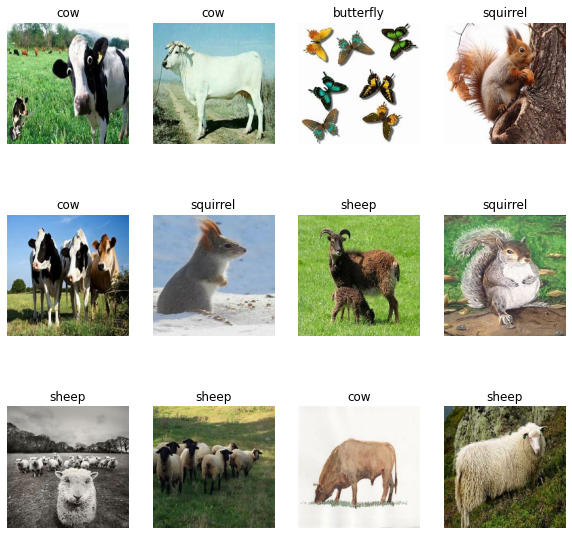

In [19]:
plot_dataset(10, 10, val_dataset, 1, 14 )

## Creation of the model

The first layer must be an input layer with the size of each image sample, i.e. img_width, img_height, numb_channels. The samples are RGB images where each channel can assume values in the range [0,255]. It is better to normalize the values in order to have a range of [0,1] for improving the stability of the model. Therefore, the first layer of the model **tf.keras.layers.Rescaling** will standardize the data. 

In [20]:
numb_classes = len(class_names)

Let's parametrize the number of couples of convolutional layer and maxpooling layers that e want to employ:

In [34]:
# NUmber of Conv2D + MaxPooling layers  
numb_conv_layers = 1

In [35]:
list_layers = [
    tf.keras.layers.InputLayer(input_shape=(img_width, img_height, numb_channels)),
    tf.keras.layers.Rescaling(1./255)
]


for i in range(numb_conv_layers):
  list_layers.append(tf.keras.layers.Conv2D(32, 3, activation='relu'))
  list_layers.append(tf.keras.layers.MaxPooling2D())

list_layers.append(tf.keras.layers.Flatten())
list_layers.append(tf.keras.layers.Dense(128, activation='relu'))
list_layers.append(tf.keras.layers.Dense(numb_classes))


In [36]:
model = tf.keras.Sequential(list_layers)

In [37]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_2 (Rescaling)     (None, 180, 180, 3)       0         
                                                                 
 conv2d_3 (Conv2D)           (None, 178, 178, 32)      896       
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 89, 89, 32)       0         
 2D)                                                             
                                                                 
 flatten_1 (Flatten)         (None, 253472)            0         
                                                                 
 dense_2 (Dense)             (None, 128)               32444544  
                                                                 
 dense_3 (Dense)             (None, 5)                 645       
                                                      

In [ ]:
EPOCHS = 20

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs = EPOCHS,
    steps_per_epoch=int(np.ceil(num_tr_samples/ float(batch_size))),
    validation_steps=int(np.ceil(num_val_samples / float(batch_size)))
)

Epoch 1/20
20/20 [==============================] - 15s 484ms/step - loss: 9.1646 - accuracy: 0.2536 - val_loss: 1.6370 - val_accuracy: 0.3835
Epoch 2/20
20/20 [==============================] - 13s 472ms/step - loss: 1.4376 - accuracy: 0.4015 - val_loss: 1.2914 - val_accuracy: 0.4813
Epoch 3/20
20/20 [==============================] - 13s 467ms/step - loss: 1.1820 - accuracy: 0.5358 - val_loss: 1.1446 - val_accuracy: 0.5151
Epoch 4/20
20/20 [==============================] - 13s 470ms/step - loss: 0.9992 - accuracy: 0.6168 - val_loss: 1.0340 - val_accuracy: 0.6054
Epoch 5/20
20/20 [==============================] - 13s 473ms/step - loss: 0.8286 - accuracy: 0.7157 - val_loss: 0.9697 - val_accuracy: 0.6294
Epoch 6/20
20/20 [==============================] - 15s 510ms/step - loss: 0.6837 - accuracy: 0.7743 - val_loss: 0.9055 - val_accuracy: 0.6521
Epoch 7/20
20/20 [==============================] - 13s 472ms/step - loss: 0.5743 - accuracy: 0.8193 - val_loss: 0.9249 - val_accuracy: 0.6325

In [ ]:
# https://www.tensorflow.org/tutorials/load_data/images

## Plotting  accuracies and losses vs epochs 

In [ ]:
def plot_accuracy_loss(history,epochs, figsize=(8,4), ymax = 1.0):

    train_loss = history.history['loss']
    train_accuracy = history.history['accuracy']
    val_loss = history.history['val_loss']
    val_accuracy = history.history['val_accuracy']
    
    ymin = min([min(train_loss), min(train_accuracy), min(val_loss), min(val_accuracy)])
    
    fig, axs = plt.subplots(1,2, figsize = (12,4), sharey=True);
    axs[0].plot(range(epochs), train_accuracy, label = 'train');
    axs[0].plot(range(epochs), val_accuracy, label = 'val');
    axs[0].set_xlabel('Number of Epochs');
    axs[0].set_title('Accuracy vs Epochs');
    axs[0].legend(loc = 'upper right');
    axs[0].set_ylim(bottom = ymin, top=ymax)
    axs[0].set_xticks(range(epochs));

    axs[1].plot(range(epochs), train_loss, label = 'train');
    axs[1].plot(range(epochs), val_loss, label = 'val');
    axs[1].set_xlabel('Number of Epochs');
    axs[1].set_title('Loss vs Epochs');
    axs[1].legend(loc = 'upper right');
    axs[1].set_xticks(range(epochs));

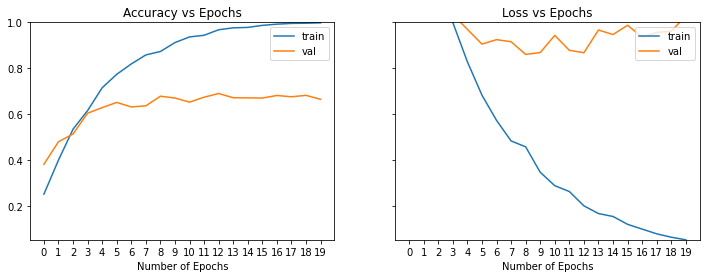

In [ ]:
plot_accuracy_loss(history, EPOCHS)

## Regularization

As we see the network with only one convolutional layer overfitted the training set having a poor accuracy (60%) on the validation set. If the training set is not large there are high chances for overfitting therefore let's increase the number of training samples via the technique of image augmentation:

In [21]:
image_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip(mode = 'horizontal_and_vertical'),
    # Random rotation in the range [-0.2 * 2pi, 0.2* 2 pi]
    tf.keras.layers.RandomRotation(factor = 0.2), 
    tf.keras.layers.RandomZoom(height_factor = 0.2 )
])

In [22]:
def show_image_augmentation(dataset, fig_width = 8, fig_height = 4): 
  fig, (ax1,ax2) = plt.subplots(1,2, figsize=(fig_width, fig_height))
  # loading the first batch
  for images, labels in dataset.take(1):
      ax1.imshow(images[1].numpy().astype("uint8"))
      ax1.set_title('original')
      ax2.imshow(image_augmentation(images[1]).numpy().astype("uint8"))
      ax2.set_title('modified')

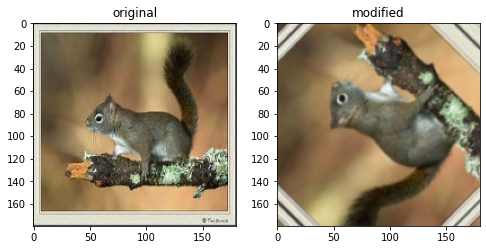

In [23]:
show_image_augmentation(train_dataset)

Now, we can apply the transormation defined previously to the train dataset: each couple (image, label) will be transformed in the corresponding (transformed image, label):

In [32]:
# The flag training indicates to aument only images in the training set 

AUTOTUNE = tf.data.AUTOTUNE
augmented_dataset = train_dataset.map(lambda image, label: \
                                      (image_augmentation(image, training = True), label), \
                                      num_parallel_calls = AUTOTUNE) 

In [33]:
augmented_dataset.prefetch(buffer_size=AUTOTUNE)

<PrefetchDataset element_spec=(TensorSpec(shape=(None, 180, 180, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [ ]:
#https://www.tensorflow.org/tutorials/images/data_augmentation

In [ ]:
EPOCHS = 20

history = model.fit(
    augmented_dataset,
    validation_data=val_dataset,
    epochs = EPOCHS,
    steps_per_epoch=int(np.ceil(num_tr_samples/ float(batch_size))),
    validation_steps=int(np.ceil(num_val_samples / float(batch_size)))
)

Epoch 1/20


## Saving the model using a .hdf5 file

We first create a folder where to put the versions of the model:

In [ ]:
saved_models_path = os.path.join('.', 'saved_hdf5_models')

In [ ]:
os.mkdir(saved_models_path)

Then, we create a function to retun the current date and time to embed in the name of the hdf5 file:

In [ ]:
from datetime import datetime

def current_date():
    now = str(datetime.now()).replace('-','').replace(' ','_').replace(':','.')
    return now[:17]

And we save the file:

In [ ]:
filename = os.path.join(saved_models_path, '{}.h5'.format( current_date() ))
model.save(filename)

## Reload the model 

In [ ]:
filename = os.path.join(saved_models_path, '20221225_16.01.05.h5')
reloaded = tf.keras.models.load_model(filename)

In [ ]:
EPOCHS = 3

history = reloaded.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs = EPOCHS,
    steps_per_epoch=int(np.ceil(num_tr / float(batch_size))),
    validation_steps=int(np.ceil(num_val / float(batch_size)))
)

## Save the results of different models in a hdf5 file via pandas

In [ ]:
import pandas as pd 

In [ ]:
df = pd.DataFrame(columns=['model_name', 'train_accuracy', 'val_accuracy'])

# saving into a file hdf5
df.to_hdf(os.path.join(saved_models_path, 'results.h5'), key ='df')



In [ ]:
pd.read_hdf('./saved_hdf5_models/results.h5')

In [ ]:
3*1302/4

In [ ]:
tf.keras.utils.image_dataset_from_directory?

In [ ]:
tf.keras.layers.RandomFlip?